Saving rotated_by_15_Screen Shot 2018-06-12 at 8.48.32 PM.png to rotated_by_15_Screen Shot 2018-06-12 at 8.48.32 PM.png


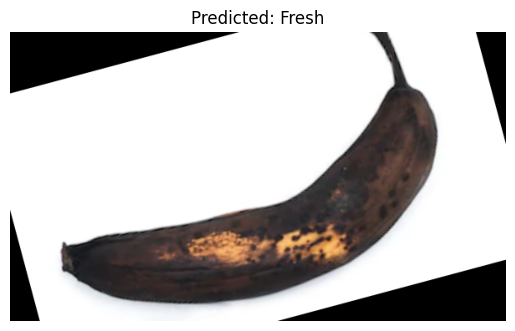

The uploaded image is classified as: Fresh


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import zipfile
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ViT Hyperparameters
IMG_SIZE = 224  # Image size (224x224 like in original ViT paper)
PATCH_SIZE = 16  # Patch size
NUM_CLASSES = 2  # Fresh vs Stale
EMBED_DIM = 256  # Embedding dimension
NUM_HEADS = 8  # Number of attention heads
NUM_LAYERS = 6  # Number of transformer blocks
MLP_DIM = 512  # MLP size in transformer
DROPOUT = 0.1  # Dropout rate

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels=3, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)  # Convert to (B, num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # Expand class token
        x = torch.cat([cls_tokens, x], dim=1)  # Concatenate class token
        x += self.pos_embed  # Add positional embedding
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.mha(self.ln1(x), self.ln1(x), self.ln1(x))[0]  # Self-attention
        x = x + self.mlp(self.ln2(x))  # MLP block
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, embed_dim, num_heads, num_layers, mlp_dim, num_classes, dropout):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim)
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder(embed_dim, num_heads, mlp_dim, dropout) for _ in range(num_layers)])
        self.ln = nn.LayerNorm(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)  # Classification head

    def forward(self, x):
        x = self.patch_embed(x)  # Patch embedding
        x = self.transformer_blocks(x)  # Transformer layers
        x = self.ln(x[:, 0])  # Take CLS token output
        x = self.fc(x)  # Classification head
        return x

# Image Preprocessing Function
def preprocess_image(img_path):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Image not found or could not be loaded: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = transform(img).unsqueeze(0)  # Add batch dimension
    return img, cv2.imread(img_path)

# Load Model
model = VisionTransformer(IMG_SIZE, PATCH_SIZE, EMBED_DIM, NUM_HEADS, NUM_LAYERS, MLP_DIM, NUM_CLASSES, DROPOUT)
model.eval()

# Upload and Process Imagesta
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
image_tensor, original_image = preprocess_image(img_path)

# Perform Inference
with torch.no_grad():
    output = model(image_tensor)
    prediction = torch.argmax(output, dim=1).item()
    label = "Fresh" if prediction == 0 else "Stale"

    # Display Image with Prediction
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {label}")
    plt.axis("off")
    plt.show()

print(f"The uploaded image is classified as: {label}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using dataset path: /content/fruits/data set
✅ Classes found: ['fresh_apple', 'fresh_banana', 'fresh_bitter_gourd', 'fresh_capsicum', 'fresh_orange', 'fresh_tomato', 'stale_apple', 'stale_banana', 'stale_bitter_gourd', 'stale_capsicum', 'stale_orange', 'stale_tomato']
✅ Train images: 11745 | Test images: 2937


<ipython-input-2-deaa27ce997a>:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()  # Mixed precision training



🚀 Training Started...



<ipython-input-2-deaa27ce997a>:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/10] - Loss: 0.2228, Accuracy: 92.76%
Epoch [2/10] - Loss: 0.0997, Accuracy: 96.76%
Epoch [3/10] - Loss: 0.1003, Accuracy: 96.59%
Epoch [4/10] - Loss: 0.0252, Accuracy: 99.12%
Epoch [5/10] - Loss: 0.0365, Accuracy: 98.77%
Epoch [6/10] - Loss: 0.0278, Accuracy: 99.00%
Epoch [7/10] - Loss: 0.0089, Accuracy: 99.63%
Epoch [8/10] - Loss: 0.0113, Accuracy: 99.58%
Epoch [9/10] - Loss: 0.0113, Accuracy: 99.63%
Epoch [10/10] - Loss: 0.0086, Accuracy: 99.74%

🎉 Training Complete!
✅ Model saved at /content/drive/MyDrive/project school stale fruit detection/data set zip.zip

📊 Test Loss: 0.0031
✅ Test Accuracy: 99.90%
📂 Upload an image for prediction:


Saving BBBBBBBBBB.webp to BBBBBBBBBB.webp


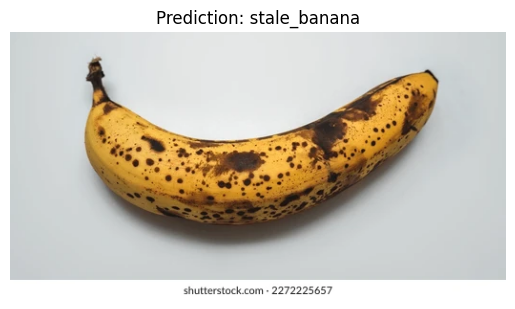

🍏 Predicted Label: stale_banana


In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision.models.vision_transformer import vit_b_16
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive, files  # Import Drive to access dataset

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')  # Mount Google Drive
drive_path = '/content/drive/MyDrive/project school stale fruit detection/data set zip.zip'  # Update with your Drive dataset path
dataset_root = '/content/fruits'  # Extracted dataset folder path

# 2️⃣ Extract Dataset
if not os.path.exists(dataset_root):  # Extract dataset only if not already done
    with zipfile.ZipFile(drive_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_root)
    print("✅ Dataset extracted successfully!")

# Ensure correct dataset path
subfolders = [f.name for f in os.scandir(dataset_root) if f.is_dir()]
dataset_path = os.path.join(dataset_root, subfolders[0]) if len(subfolders) == 1 else dataset_root

print("✅ Using dataset path:", dataset_path)

# 3️⃣ Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 4️⃣ Load Dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("✅ Classes found:", dataset.classes)
print("✅ Train images:", len(train_dataset), "| Test images:", len(test_dataset))

# 5️⃣ Define Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)  # Dynamically determine the number of classes

model = vit_b_16(weights="IMAGENET1K_V1")
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model = model.to(device)

# 6️⃣ Define Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
scaler = GradScaler()  # Mixed precision training

# 7️⃣ Train Model
num_epochs = 10
print("\n🚀 Training Started...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("\n🎉 Training Complete!")

# 8️⃣ Save Model
model_path = "/content/drive/MyDrive/project school stale fruit detection/data set zip.zip"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")

# 9️⃣ Evaluate Model
model.eval()
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"\n📊 Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.2f}%")

# 🔟 Predict Fresh or Stale for a Single Image
def predict_fruit_freshness():
    print("📂 Upload an image for prediction:")
    uploaded = files.upload()

    if uploaded:
        for image_name in uploaded.keys():
            image_path = image_name
            image = Image.open(image_path).convert("RGB")
            transformed_image = transform(image).unsqueeze(0).to(device)

            # Make prediction
            with torch.no_grad():
                output = model(transformed_image)
                _, predicted_class = torch.max(output, 1)

            class_names = dataset.classes
            predicted_label = class_names[predicted_class.item()]

            # Display image
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"Prediction: {predicted_label}")
            plt.show()

            print(f"🍏 Predicted Label: {predicted_label}")

# 🔹 Call Prediction Function
predict_fruit_freshness()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')